Método das diferenças finitas linear $O(h^2)$:

In [102]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import math

In [103]:
def p(x):
    return -2/x

def q(x):
    return 2/(x**2)

def r(x):
    return np.sin(np.log(x))/(x**2)

c2 = 1/(70) * (8 - 12*np.sin(np.log(2)) - 4*np.cos(np.log(2)))
c1 = 11/10 - c2
def real_f(x):
    return c1*x + c2/(x**2) - (3/10) * np.sin(np.log(x)) - (1/10)*np.cos(np.log(x))

In [104]:
def thomas_algorithm(a,b,d,B,ti,tf,h,alpha,beta):
    N = len(b)
    y = np.zeros(N)
    a[0] = a[0]/d[0]
    B[0] = B[0]/d[0]

    for i in range(1, N - 1):
        a[i]  = a[i] / (d[i] - b[i]*a[i - 1])
        B[i] = (B[i] - b[i]*B[i - 1]) / (d[i] - b[i]*a[i - 1])

    B[N - 1] = (B[N - 1] - b[N - 1]*B[N - 2]) / (d[N - 1] - b[N - 1]*a[N - 2])
    y[N - 1] = B[N - 1]

    for i in range(N - 2, -1, -1):
        y[i] = B[i] - a[i]*y[i + 1]

    return y

In [105]:
def diferencas_finitas(ti,tf,h,alpha,beta,p,q,r):
    N = int(np.round((tf - ti)/h))
    t = np.linspace(ti,tf,N + 1)
    n_sistema = (N + 1) - 2

    y = np.zeros(N + 1)
    a = np.zeros(n_sistema) #Diagonal principal
    b = np.zeros(n_sistema) #Diagonal superior
    d = np.zeros(n_sistema) #Resultados
    c = np.zeros(n_sistema) #Diagonal inferior

    a[0] = 2 + (h**2) * q(t[1])
    b[0] = -1 + (h/2)* p(t[1])
    d[0] = -(h**2)*r(t[1]) + (1 + (h/2)*p(t[1]))*alpha

    for i in range(1, n_sistema - 1):
        a[i] = 2 + (h**2)*q(t[i + 1])
        b[i] = -1 + (h/2)*p(t[i + 1])
        c[i] = -1 - (h/2)*p(t[i + 1])
        d[i] = -(h**2)*r(t[i + 1])

    a[n_sistema - 1] = 2 + (h**2)*q(t[N - 1])
    c[n_sistema - 1] = -1 -(h / 2)*p(t[N - 1])
    d[n_sistema - 1] = -(h**2)*r(t[N - 1]) + (1 - (h/2)*p(t[N - 1]))*beta

    #Algorítmo de Thomas
    y[0] = alpha
    y[-1] = beta
    y[1:-1] = thomas_algorithm(b,c,a,d,ti,tf,h,alpha,beta)

    return t,y

In [106]:
t_1,y_1= diferencas_finitas(1,2,0.5,1,2,p,q,r)

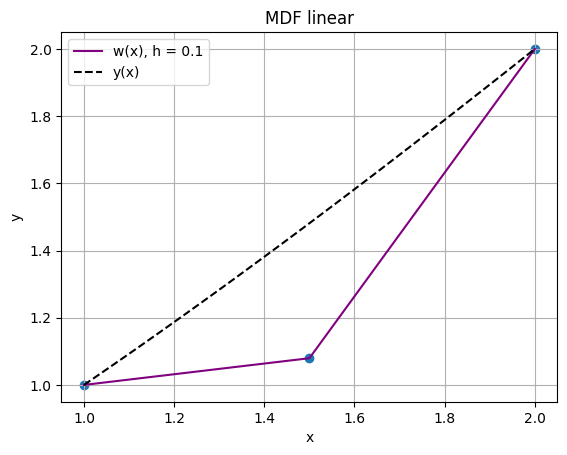

In [107]:
t_real = np.linspace(1,2)
plt.plot(t_1,y_1, label = f"w(x), h = {0.1}", color = '#800080')
plt.plot(t_real,real_f(t_real), label = "y(x)", linestyle = '--', color = "black")
plt.title("MDF linear")
plt.xlabel("x")
plt.ylabel("y")
plt.scatter(t_1,y_1)
plt.legend()
plt.grid()
plt.show()

Erro absoluto:

In [108]:
abs(real_f(t_1) - y_1)

array([0.        , 0.40163714, 0.        ])

Método das diferenças finitas: $O(h^4)$

In [109]:
import numpy as np
from scipy.sparse import lil_matrix
from scipy.sparse.linalg import spsolve

def diferencas_finitas_ordem4(ti, tf, h, alpha, beta, p, q, r):
    N = int(np.round((tf - ti)/h))
    x = np.linspace(ti, tf, N + 1)
    n_sistema = (N + 1) - 2

    A = lil_matrix((n_sistema, n_sistema))
    results = np.zeros(n_sistema) # Matriz (vetor) de resultados

    for i in range(n_sistema):
        idx = i + 1
        results[i] = 12 * h**2 * r(x[idx])
    
        # Estêncil Progressivo (Primeira linha interna)
        if i == 0:
            A[i, i]   = -15 + 10*h*p(x[idx]) - 12*h**2*q(x[idx])
            A[i, i+1] = -4 - 18*h*p(x[idx])
            A[i, i+2] = 14 + 6*h*p(x[idx])
            A[i, i+3] = -6 - h*p(x[idx])
            A[i, i+4] = 1
            
            results[i] -= (10 + 3*h*p(x[idx])) * alpha
        
        # Estêncil Regressivo
        elif i == n_sistema - 1:
            A[i, i-4] = 1
            A[i, i-3] = -6 + h*p(x[idx])
            A[i, i-2] = 14 - 6*h*p(x[idx])
            A[i, i-1] = -4 + 18*h*p(x[idx])
            # Correção 2: Adicionado o termo q(x) na diagonal principal
            A[i, i]   = -15 - 10*h*p(x[idx]) - 12*h**2*q(x[idx])
            
            # Aplica a condição de contorno beta (termo y_{idx+1})
            results[i] -= (10 - 3*h*p(x[idx])) * beta
        
        
        # Estêncil Central Simétrico
        else:
            c_im2 = -1 - h*p(x[idx])   # Coeficiente de y_{idx-2}
            c_im1 = 16 + 8*h*p(x[idx]) # Coeficiente de y_{idx-1}
            c_i   = -30 - 12*h**2*q(x[idx])
            c_ip1 = 16 - 8*h*p(x[idx]) # Coeficiente de y_{idx+1}
            c_ip2 = -1 + h*p(x[idx])   # Coeficiente de y_{idx+2}

            # Trata o vizinho traseiro esquerdo se bater no contorno alpha (i=1)
            if i - 2 < 0: 
                results[i] -= c_im2 * alpha
            else:
                A[i, i-2] = c_im2
                
            A[i, i-1] = c_im1
            A[i, i]   = c_i
            A[i, i+1] = c_ip1
            
            # Trata o vizinho dianteiro direito se bater no contorno beta (i=n_sistema-2)
            if i + 2 >= n_sistema:
                results[i] -= c_ip2 * beta
            else:
                A[i, i+2] = c_ip2

    A = A.tocsr()
    y_internos = spsolve(A, results)
    
    y_final = np.zeros(N + 1)
    y_final[0] = alpha
    y_final[1:-1] = y_internos
    y_final[-1] = beta

    return x, y_final

In [110]:
t_1,y_1= diferencas_finitas_ordem4(1,2,0.1,1,2,p,q,r)

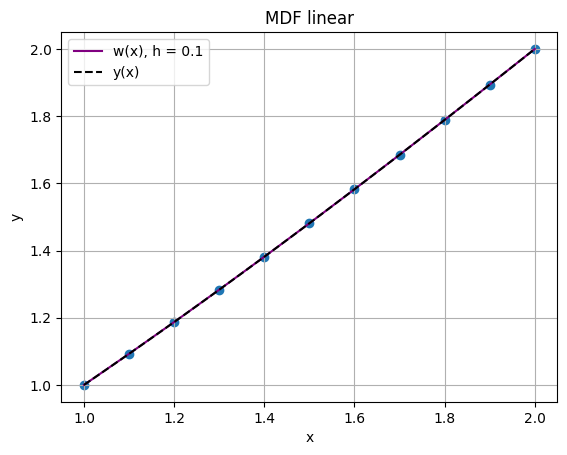

In [111]:
t_real = np.linspace(1,2)
plt.plot(t_1,y_1, label = f"w(x), h = {0.1}", color = '#800080')
plt.plot(t_real,real_f(t_real), label = "y(x)", linestyle = '--', color = "black")
plt.title("MDF linear")
plt.xlabel("x")
plt.ylabel("y")
plt.scatter(t_1,y_1)
plt.legend()
plt.grid()
plt.show()

Erro absoluto:

In [112]:
abs(real_f(t_1) - y_1)

array([0.00000000e+00, 2.38050364e-06, 1.82625684e-06, 1.32329404e-06,
       9.68888836e-07, 7.15335359e-07, 5.27867354e-07, 3.84853444e-07,
       2.72152838e-07, 1.74398317e-07, 0.00000000e+00])